In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Đọc cả 2 tập dữ liệu (Lưu ý: đặt đúng đường dẫn thư mục Data của bạn)
df_mat = pd.read_csv('Data/student-mat.csv', sep=';')
df_por = pd.read_csv('Data/student-por.csv', sep=';')

# Thêm cột 'subject' để phân biệt môn Toán (Math) và Tiếng Bồ Đào Nha (Por)
df_mat['subject'] = 'Math'
df_por['subject'] = 'Por'

# Gộp 2 DataFrame lại theo chiều dọc
df = pd.concat([df_mat, df_por], ignore_index=True)

print(f"Tổng số học sinh sau khi gộp: {df.shape[0]} học sinh")
display(df.head())

Tổng số học sinh sau khi gộp: 1044 học sinh


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math


In [2]:
# Sao chép dataframe để tránh làm thay đổi dữ liệu gốc
df_processed = df.copy()

# Xử lý biến phân loại (Categorical) bằng LabelEncoder
categorical_cols = df_processed.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Phân chia Đặc trưng (X) và Biến mục tiêu (y)
# Drop G1, G2 để tránh "Data Leakage" (Học vẹt từ điểm quá trình)
X = df_processed.drop(['G1', 'G2', 'G3'], axis=1)
y = df_processed['G3']

# Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Feature Scaling) - Giúp Hồi quy tuyến tính hội tụ tốt hơn
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Kích thước X_train:", X_train_scaled.shape)
print("Kích thước X_test:", X_test_scaled.shape)

Kích thước X_train: (835, 31)
Kích thước X_test: (209, 31)


In [3]:
# Khởi tạo mô hình
lr_model = LinearRegression()

# Huấn luyện mô hình
lr_model.fit(X_train_scaled, y_train)

# Dự đoán trên tập Test
y_pred = lr_model.predict(X_test_scaled)

In [4]:
# Tính toán các chỉ số đánh giá
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION:")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error):      {mae:.4f}")
print(f"R-squared (R2 Score):           {r2:.4f}")

ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION:
RMSE (Root Mean Squared Error): 3.6603
MAE (Mean Absolute Error):      2.6248
R-squared (R2 Score):           0.1334


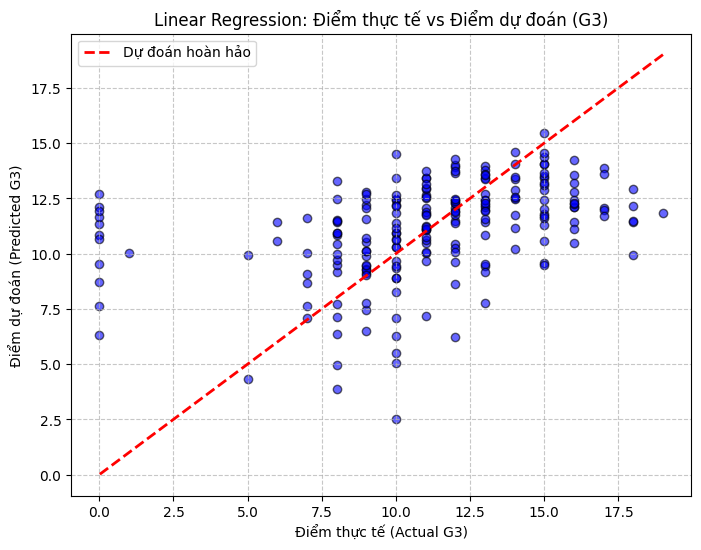

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolor='k')

# Vẽ đường chéo y = x (Đường dự đoán hoàn hảo)
p1 = max(max(y_pred), max(y_test))
p2 = min(min(y_pred), min(y_test))
plt.plot([p1, p2], [p1, p2], 'r--', lw=2, label='Dự đoán hoàn hảo')

plt.title('Linear Regression: Điểm thực tế vs Điểm dự đoán (G3)')
plt.xlabel('Điểm thực tế (Actual G3)')
plt.ylabel('Điểm dự đoán (Predicted G3)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()